In [ ]:
import os
import numpy as np
import cv2  # for image loading and resizing


def load_plantdoc_data(data_dir, img_size=(299, 299)):
    X = []
    y = []
    class_names = sorted(os.listdir(data_dir))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    for cls_name in class_names:
        cls_dir = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_to_idx[cls_name])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y, class_names


In [ ]:
from google.colab import drive

# Step 1: Mount Google Drive (only once)
drive.mount('/content/drive')

# Step 2: Correct path to your dataset folder inside Google Drive
dataset_root = '/content/drive/MyDrive/PlantDoc-Dataset'  # Corrected path
train_dir = f'{dataset_root}/train'
test_dir = f'{dataset_root}/test'

# Step 3: Call your loading function correctly
X_train, y_train, class_names = load_plantdoc_data(train_dir)
X_test, y_test, _ = load_plantdoc_data(test_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2: Normalize Images

In [ ]:
def preprocess_images(X):
    """
    Normalize images to [0,1] range
    """
    return X / 255.0

X_train = preprocess_images(X_train)
X_test = preprocess_images(X_test)


Step 3: Create Validation Dataset from Training Data

In [ ]:
from sklearn.model_selection import train_test_split

def create_validation_split(X_train, y_train, val_size=0.2):
    """
    Split training data into train and validation sets with stratification
    """
    return train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=42
    )

X_train, X_val, y_train, y_val = create_validation_split(X_train, y_train, val_size=0.2)


Step 4: Convert Labels to One-Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


Step 5: Build a Keras Model (Xception)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models, optimizers

def build_xception_model(num_classes, input_shape=(299, 299, 3)):
    # Load the pre-trained Xception model without the top classification layer
    base_model = Xception(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Freeze base model layers

    # Build your custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Example usage:
model = build_xception_model(num_classes=27)
model.summary()  # Adjust num_classes to your dataset

Step 6: Train the Model with Early Stopping and Learning Rate Reduction

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-7)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 971s 17s/step - accuracy: 0.2398 - loss: 3.0052 - val_accuracy: 0.3944 - val_loss: 2.1239 - learning_rate: 0.0010
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 950s 16s/step - accuracy: 0.5492 - loss: 1.4432 - val_accuracy: 0.4892 - val_loss: 1.7103 - learning_rate: 0.0010
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 989s 17s/step - accuracy: 0.6629 - loss: 1.0602 - val_accuracy: 0.5108 - val_loss: 1.5842 - learning_rate: 0.0010
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 980s 17s/step - accuracy: 0.7467 - loss: 0.8216 - val_accuracy: 0.5151 - val_loss: 1.5408 - learning_rate: 0.0010
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 942s 16s/step - accuracy: 0.7816 - loss: 0.7324 - val_accuracy: 0.5172 - val_loss: 1.5561 - learning_rate: 0.0010
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 982s 16s/step - accuracy: 0.7875 - loss: 0.6560 - val_accuracy: 0.5129 - val_loss: 1.5689 - learning_rate: 0.0010
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 983s 16s/step - accuracy: 0.8291 - loss: 0.5232 - 

Step 7: Evaluate the Model on Test Data

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)
y_true = y_test_cat.argmax(axis=1)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
report = classification_report(y_true, y_pred, target_names=class_names)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Weighted F1 Score: {f1:.4f}")
print("Classification Report:\n", report)


8/8 ━━━━━━━━━━━━━━━━━━━━ 99s 12s/step
Test Accuracy: 0.5042
Test Weighted F1 Score: 0.4997
Classification Report:
                             precision    recall  f1-score   support

           Apple Scab Leaf       0.44      0.80      0.57        10
                Apple leaf       0.50      0.67      0.57         9
           Apple rust leaf       0.75      0.60      0.67        10
          Bell_pepper leaf       0.50      0.62      0.56         8
     Bell_pepper leaf spot       0.20      0.11      0.14         9
            Blueberry leaf       0.25      0.18      0.21        11
               Cherry leaf       0.60      0.30      0.40        10
       Corn Gray leaf spot       0.17      0.50      0.25         4
          Corn leaf blight       0.80      0.33      0.47        12
            Corn rust leaf       0.78      0.70      0.74        10
                Peach leaf       0.67      0.67      0.67         9
  Potato leaf early blight       0.27      0.38      0.32         8


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


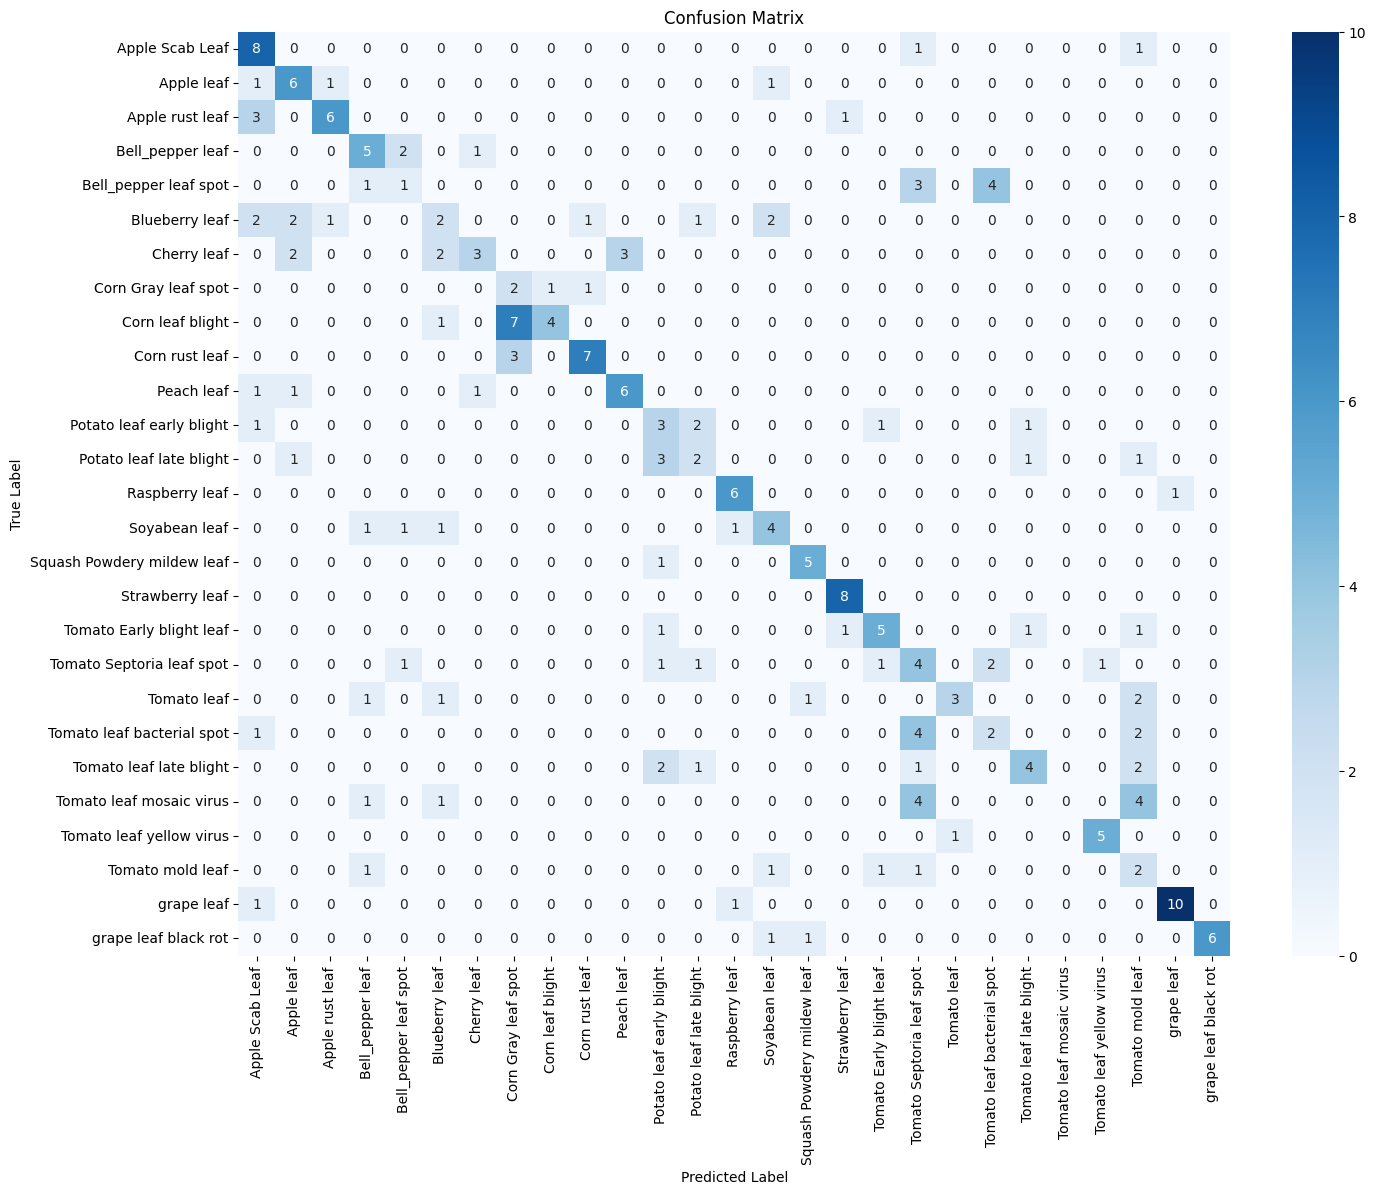

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


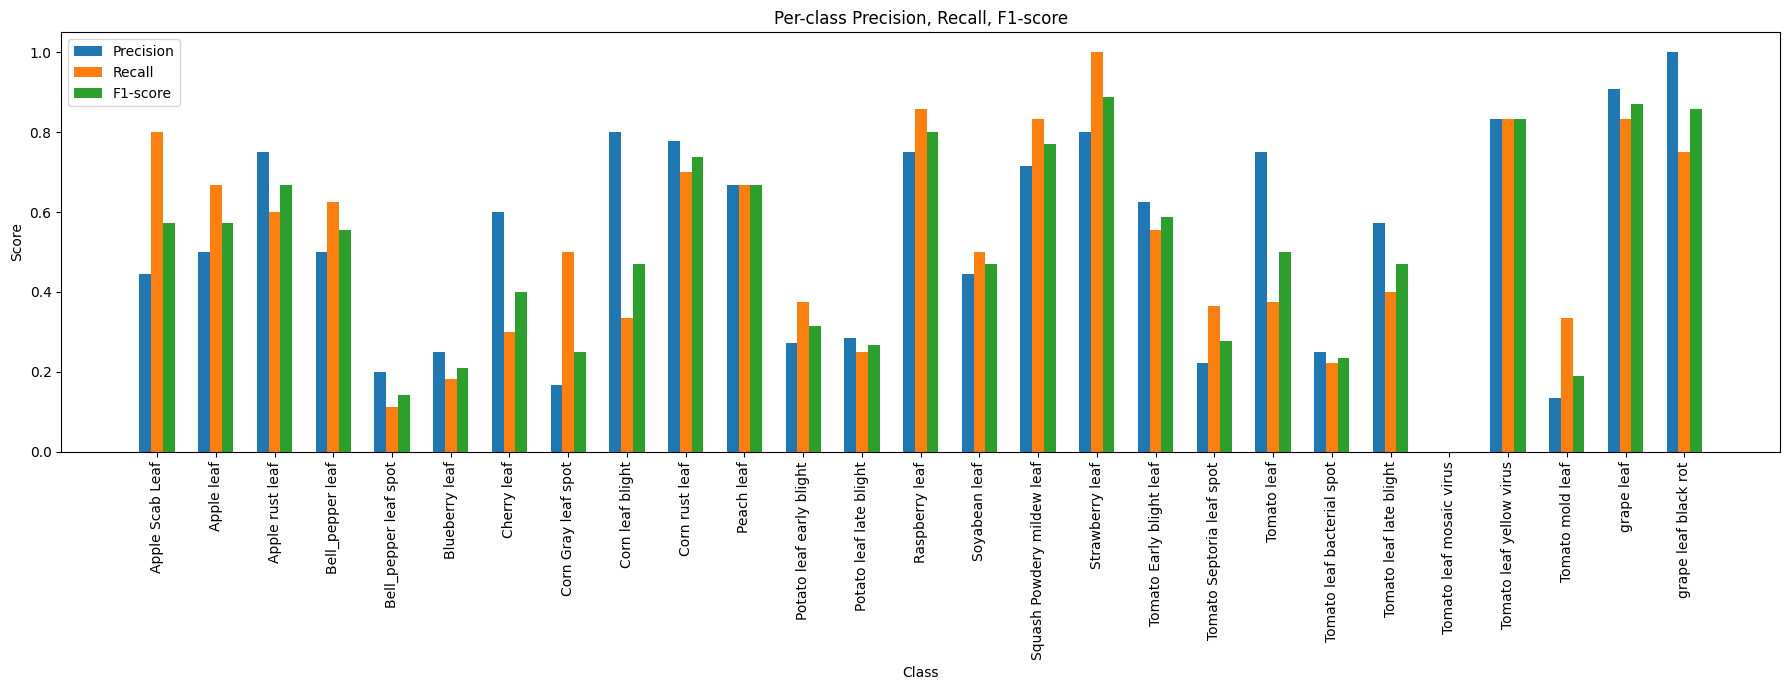

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(len(class_names)))

x = np.arange(len(class_names))
plt.figure(figsize=(18,7))
plt.bar(x-0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x+0.2, f1, width=0.2, label='F1-score')
plt.xticks(x, class_names, rotation=90)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-class Precision, Recall, F1-score")
plt.legend()
plt.tight_layout()
plt.show()
